# Gym Membership Churn Analysis
---

## Executive Summary  
We analyze gym member behavior to understand churn patterns and build a predictive model that flags at-risk members. The final model achieves **97% ROC-AUC** and **92% precision at 80% recall**, providing strong performance in identifying likely churners. We find key churn drivers — including **short tenure**, **low class attendance**, and **impending contract expiry** — and segment members into **four risk tiers**. These tiers are translated into actionable personas that guide targeted retention strategies. The model outputs can be integrated into CRM systems to prioritize outreach and reduce member attrition.

## Table of Contents
---

- [Introduction](#Introduction)  
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)  
- [Cohort Analysis](#Cohort-Analysis)  
- [Building a Predictive Model](#Building-a-Predictive-Model)  
- [Feature Importance](#Feature-Importance)  
- [Catching 80% of Churners](#Catching-80-of-Churners)  
- [Building Churn Risk Tiers and Personas](#Building-Churn-Risk-Tiers-and-Personas)
- [Business Insights and Recommendations](#Business-Insights-and-Recommendations)  
- [Making Predictions in Practice](#Making-Predictions-in-Practice)  
- [Data Quality and Recommendations](#Data-Quality-and-Recommendations)  

## Introduction
---

This notebook explores gym member churn — when and why members cancel their memberships. We analyze demographic, behavioral, and contract data to uncover churn patterns and build a machine learning model that predicts churn risk.

Churn is a major cost driver in subscription-based businesses like gyms. This analysis helps identify high-risk members and enables interventions such as personalized outreach and contract redesign.

## Notebook Structure
---

- **Exploratory Data Analysis:** Visualize churn patterns across categorical and numerical features; use t-tests and chi-square tests to identify significant differences.
- **Cohort Analysis:** Analyze member tenure cohorts to compare churn rates and engagement over time.
- **Building a Predictive Model:** Train a Random Forest classifier and evaluate performance using ROC-AUC and PR-AUC.
- **Feature Importance:** Identify the most influential features using permutation importance and built-in model metrics.
- **Catching 80% of Churners:** Analyze precision-recall trade-offs at different decision thresholds to find a practical operating point.
- **Building Churn Risk Tiers and Personas:** Segment members into four risk tiers and define representative personas for targeting.
- **Making Predictions in Practice:** Demonstrate how the model can be applied to new member data in a deployment setting.
- **Business Insights and Recommendations:** Summarize key findings and outline actionable strategies for retention.
- **Data Quality and Recommendations:** Highlight data limitations and propose ideas for improving future churn prediction efforts.


## Exploratory Data Analysis
---

We first explore the dataset to understand its structure and uncover patterns that may influence cancellation behavior.


### About the Data

The dataset captures **member activity and contract details from the prior month**, along with whether they **churned in the current month**. Features include:
- **Contract**
    - Contract_period - The customer's contract period in months.
    - Month_to_end_contract - Months until the current contract ends.
    - Group_visits - Whether the customer's membership allows to bring friends.
    - Promo_friends - If the user originally signed up through a "bring a friend" offer (they used a friend's promotional code when they paid the first subscription).
- **Behavioral**
    - Avg_additional_charges_total - Additional charges on the customer's account.
    - Avg_class_frequency_total - Average number of classes the customer attended (not clear from data if this is per week, per month, or other).
    - Avg_class_frequency_current_month - Average number of classes the customer attended in the current month.
    - Lifetime - The time (in months) since the user first arrived at the gym.
- **Demographic**
    - Partner - If the user works in an associated company (the gym has associated companies whose employees get discounts; in those cases, the gym stores information about the clients' employers).
    - Gender - The user's gender (0 or 1, not clear which is male and female).
    - Age - The customer's age.
    - Phone - If the user provided their phone number.
    - Near_Location - If the user lives or works in the neighborhood where the gym is located.
- **Churn** - Cancellation for the current month.

### Key Findings
- Members are less likely to churn if they live closer to the gym, work at a partner company, signed up with the friend promo, have a longer contract, and/or are allowed to bring friends.
- Churners tend to be younger (27 vs. 30 for non-churners), and attend fewer classes (1 vs. 2 average classes/month).
- Gender and whether the customer added a phone number do not affect churn.
- Statistical testing confirms the above patterns:
    - T-tests show all numerical differences are statistically significant (p < 0.001), with large effects for membership lifetime and class attendance.
    - Chi-square tests show contract length is most strongly linked to churn (Cramér’s V = 0.40), followed by group visits, friend promo, and partner status (V ≈ 0.16–0.18).

Many of the trends uncovered here will reappear in the predictive model discussion.

In [1]:
# Import libraries and set display options
# Note: to install the package `minieda`, run `pip install git+https://github.com/dbolotov/minieda.git`

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from minieda import summarize
from scipy.stats import ttest_ind, t, chi2_contingency

import time
from pprint import pprint

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import average_precision_score, precision_recall_curve, \
    precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

pd.set_option("display.precision", 2)

In [2]:
# Define a function for printing tables
def style_table(df, caption, precision=1, caption_side="bottom", font_size="16px", font_weight="normal"):
    return (df.style
            .format(precision=precision).set_caption(caption)
            .set_table_styles([{"selector": "caption", 
                                "props": [("caption-side", caption_side),
                                          ("font-size", font_size),
                                          ("font-weight", font_weight)]}]))

In [3]:
# Display the raw dataset
df = pd.read_csv("gym_churn_us.csv")
df

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.23,5.0,3,0.02,0.00,0
1,0,1,0,0,1,12,1,31,113.20,12.0,7,1.92,1.91,0
2,0,1,1,0,1,1,0,28,129.45,1.0,2,1.86,1.74,0
3,0,1,1,1,1,12,1,33,62.67,12.0,2,3.21,3.36,0
4,1,1,1,1,1,1,0,26,198.36,1.0,3,1.11,1.12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.41,12.0,8,2.28,2.35,0
3996,0,1,0,0,1,1,1,29,68.88,1.0,1,1.28,0.29,1
3997,1,1,1,1,1,12,0,28,78.25,11.0,2,2.79,2.83,0
3998,0,1,1,1,1,6,0,32,61.91,5.0,3,1.63,1.60,0


In [4]:
# Show summary statistics for the dataset
summarize(df)

,dtype,count,unique,unique_perc,missing,missing_perc,zero,zero_perc,mean,std,min,50%,max,skew
gender,int64,4000,2,0.05,0,0.0,1959,48.98,0.51,0.50,0.00,1.00,1.00,-0.04
Near_Location,int64,4000,2,0.05,0,0.0,619,15.48,0.85,0.36,0.00,1.00,1.00,-1.91
Partner,int64,4000,2,0.05,0,0.0,2053,51.32,0.49,0.50,0.00,0.00,1.00,0.05
Promo_friends,int64,4000,2,0.05,0,0.0,2766,69.15,0.31,0.46,0.00,0.00,1.00,0.83
Phone,int64,4000,2,0.05,0,0.0,386,9.65,0.90,0.30,0.00,1.00,1.00,-2.73
Contract_period,int64,4000,3,0.08,0,0.0,0,0.00,4.68,4.55,1.00,1.00,12.00,0.71
Group_visits,int64,4000,2,0.05,0,0.0,2351,58.78,0.41,0.49,0.00,0.00,1.00,0.36
Age,int64,4000,23,0.57,0,0.0,0,0.00,29.18,3.26,18.00,29.00,41.00,-0.06
Avg_additional_charges_total,float64,4000,4000,100.00,0,0.0,0,0.00,146.94,96.36,0.15,136.22,552.59,0.62
Month_to_end_contract,float64,4000,12,0.30,0,0.0,0,0.00,4.32,4.19,1.00,1.00,12.00,0.81


In [5]:
# Create lists of categorical and numerical variables
cat_vars = ["gender", "Near_Location", "Partner",  "Promo_friends", "Phone", "Contract_period", "Group_visits"]
num_vars = ["Age", "Avg_additional_charges_total", "Month_to_end_contract", "Lifetime", "Avg_class_frequency_total", "Avg_class_frequency_current_month"]

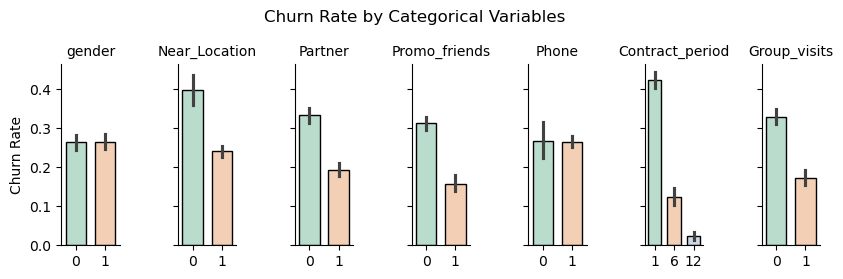

In [6]:
# Plot churn rate for categorical variables, split by categories

g = sns.FacetGrid(
    pd.melt(df, id_vars="Churn", value_vars=cat_vars),
    col="variable", col_wrap=7, sharey=True, sharex=False, height=3, aspect=0.4)
g.map_dataframe(sns.barplot, x="value", y="Churn", estimator=lambda x: sum(x)/len(x),
                width=0.7, hue="value", palette='Pastel2', edgecolor="black")
g.set_axis_labels("", "Churn Rate")
g.set_titles("{col_name}")
g.fig.suptitle("Churn Rate by Categorical Variables")
g.fig.subplots_adjust(top=0.8, wspace = 1)  # adjust to fit the title

plt.show()

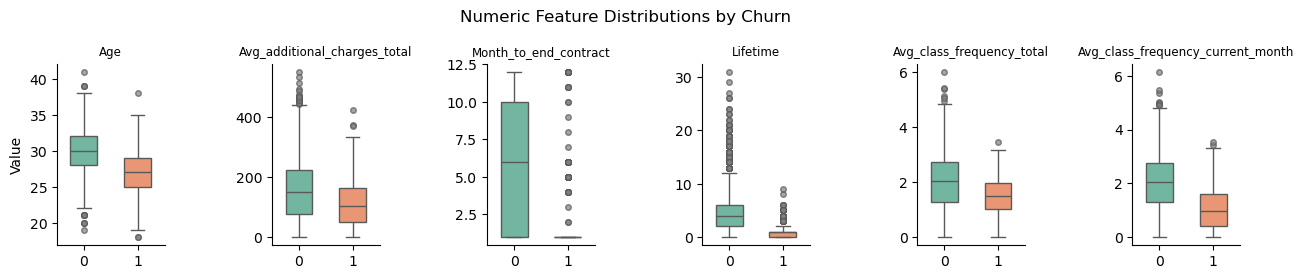

In [7]:
# Create boxplots for numeric features by churn

df_plot = df.copy()

melted = pd.melt(df_plot, id_vars="Churn", value_vars=num_vars)

g = sns.FacetGrid(melted, col="variable", sharey=False, height=3, aspect=0.7)
g.map_dataframe(sns.boxplot, x="Churn", y="value", showfliers=True, hue="Churn", palette="Set2",
                flierprops=dict(marker='o', markersize=4, markerfacecolor="gray", alpha=0.7),
                width=0.5)

g.set_titles("{col_name}", size=8.5)
g.set_axis_labels("", "Value")
g.fig.suptitle("Numeric Feature Distributions by Churn")
g.fig.subplots_adjust(top=0.8, wspace = 1)

plt.show()

In [8]:
def run_ttests_with_means(df, num_vars, churn_col="Churn", pretty=False):
    """Compare numeric variables between churners and non-churners using t-test."""
    rows = []

    for var in num_vars:
        g1 = df[df[churn_col] == 1][var].dropna()  # churners
        g0 = df[df[churn_col] == 0][var].dropna()  # non-churners

        n1, n0 = len(g1), len(g0)
        m1, m0 = g1.mean(), g0.mean()
        s1, s0 = g1.std(ddof=1), g0.std(ddof=1)

        # Welch t-test
        t_stat, p_val = ttest_ind(g1, g0, equal_var=False)

        # Mean difference and its SE
        diff = m1 - m0
        se = np.sqrt((s1**2 / n1) + (s0**2 / n0))

        # Degrees of freedom
        df_welch_num = (s1**2 / n1 + s0**2 / n0) ** 2
        df_welch_den = ((s1**2 / n1) ** 2) / (n1 - 1) + ((s0**2 / n0) ** 2) / (n0 - 1)
        dof = df_welch_num / df_welch_den

        # 95% CI for mean difference
        t_crit = t.ppf(0.975, dof)
        ci_low = diff - t_crit * se
        ci_high = diff + t_crit * se

        # Effect size: Hedges' g
        sp2 = ((n1 - 1) * s1**2 + (n0 - 1) * s0**2) / (n1 + n0 - 2)
        sp = np.sqrt(sp2)
        d = diff / sp if sp > 0 else np.nan
        J = 1 - (3 / (4*(n1 + n0) - 9))  # small sample correction
        g_hedges = d * J

        rows.append({"variable": var, "n_churn": n1, "mean_churn": m1,
            "n_non": n0, "mean_non": m0, "diff_mean": diff,
            "t_stat": t_stat, "p_value": p_val,
            "ci_low": ci_low, "ci_high": ci_high, "hedges_g": g_hedges})

    out = pd.DataFrame(rows)

    if pretty:
        out_fmt = out.copy()
        out_fmt["mean_churn"] = out_fmt["mean_churn"].map(lambda x: f"{x:.2f}")
        out_fmt["mean_non"] = out_fmt["mean_non"].map(lambda x: f"{x:.2f}")
        out_fmt["diff_mean"] = out_fmt["diff_mean"].map(lambda x: f"{x:+.2f}")
        out_fmt["t_stat"] = out_fmt["t_stat"].map(lambda x: f"{x:.2f}")
        out_fmt['p_value'] = out_fmt['p_value'].apply(lambda x: '<0.001' if x < 0.001 else f"{x:.2e}")
        out_fmt["ci"] = out.apply(lambda r: f"[{r.ci_low:.2f}, {r.ci_high:.2f}]", axis=1)
        out_fmt["hedges_g"] = out_fmt["hedges_g"].map(lambda x: f"{x:+.2f}")
    
        cols = ["variable", "mean_churn", "mean_non", "diff_mean", "t_stat", "p_value", "ci", "hedges_g"]
        return out_fmt[cols]

    return out

ttest_results = run_ttests_with_means(df, num_vars, pretty=True)
style_table(ttest_results, "Differences in Numeric Features Between Churners and Non-Churners (t-test)")

,variable,mean_churn,mean_non,diff_mean,t_stat,p_value,ci,hedges_g
0,Age,26.99,29.98,-2.99,-28.50,<0.001,"[-3.19, -2.78]",-1.00
1,Avg_additional_charges_total,115.08,158.45,-43.36,-14.39,<0.001,"[-49.27, -37.45]",-0.46
2,Month_to_end_contract,1.66,5.28,-3.62,-36.00,<0.001,"[-3.82, -3.42]",-0.93
3,Lifetime,0.99,4.71,-3.72,-46.99,<0.001,"[-3.88, -3.57]",-1.10
4,Avg_class_frequency_total,1.47,2.02,-0.55,-19.37,<0.001,"[-0.61, -0.49]",-0.58
5,Avg_class_frequency_current_month,1.04,2.03,-0.98,-32.55,<0.001,"[-1.04, -0.92]",-1.02


In [9]:
def cramers_v(confusion_matrix):
    """Calculate Cramer's V statistic for categorical-categorical association."""
    chi2 = chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def run_chi2_tests(df, cat_vars, target='Churn', pretty=True):
    """Compare categorical variables between churners and non-churners using chi-square test."""
    results = []

    for var in cat_vars:
        contingency = pd.crosstab(df[var], df[target])
        chi2, p, _, _ = chi2_contingency(contingency)
        cramers = cramers_v(contingency)

        results.append({'variable': var, 'num_cat': contingency.shape[0],
            'chi2_stat': chi2, 'p_value': p, 'cramers_v': cramers})

    results_df = pd.DataFrame(results)

    if pretty:
        results_df['chi2_stat'] = results_df['chi2_stat'].round(2)
        results_df['p_value'] = results_df['p_value'].apply(lambda x: '<0.001' if x < 0.001 else round(x, 3))
        results_df['cramers_v'] = results_df['cramers_v'].round(2)

    return results_df

chi2_results = run_chi2_tests(df, cat_vars, pretty=True)
style_table(chi2_results, "Categorical Feature Association with Churn (chi-squared test)")

,variable,num_cat,chi2_stat,p_value,cramers_v
0,gender,2,0.0,1.0,0.0
1,Near_Location,2,64.8,<0.001,0.1
2,Partner,2,99.1,<0.001,0.2
3,Promo_friends,2,104.5,<0.001,0.2
4,Phone,2,0.0,1.0,0.0
5,Contract_period,3,653.6,<0.001,0.4
6,Group_visits,2,122.2,<0.001,0.2


## Cohort Analysis

---

We segment members into four cohorts based on their `Lifetime` (months since joining) to understand how behavior and churn risk evolve over time:

- **New:** < 3 months  
- **Early:** 3–5 months  
- **Established:** 6–11 months  
- **Loyal:** 12+ months


This view complements the churn-focused exploratory analysis in the previous section by shifting from churn correlates to retention patterns, helping us frame long-term member behavior and identify opportunities over time.

### Key Findings

- **Churn is concentrated among New members:** Over 50% of churners fall within the first 3 months. After that, churn rates drop sharply — to 7% in Early, <1% in Established, and 0% in Loyal.
- **Engagement stabilizes quickly:** Class attendance rises to ~2 classes/week by the Early cohort and remains steady in later groups.
- **Age and spending vary little across cohorts:** All groups average ~28–30 years old, and additional charges show no major shifts.
- **Short contracts remain common even among loyal members:** In the Loyal cohort, nearly half (48%) still have a 1-month contract, a pattern that appears consistently across cohorts.
- **Local members are more likely to stay:** The share of members who live or work near the gym grows gradually from 82% (New) to 90% (Loyal), echoing earlier findings that proximity reduces churn.

While some of these insights mirror the earlier churn-focused EDA, cohort segmentation adds a useful retention lens — especially when identifying which behaviors *persist* vs. *change* over time.

### Business Implications

- The New and Early periods are crucial: The vast majority of churn happens in the first 3 months. Targeted onboarding campaigns, early touchpoints, and habit-building strategies could yield major retention gains.
- Retention doesn't mean increasing engagement: Members who stick around maintain consistent, moderate activity (~2 classes/week), rather than ramping up over time.
- Cohort-based opportunities for contract upsells: Many long-term, loyal members remain on flexible 1-month plans. Offering incentives to switch to longer-term contracts could boost revenue predictability with minimal churn risk.

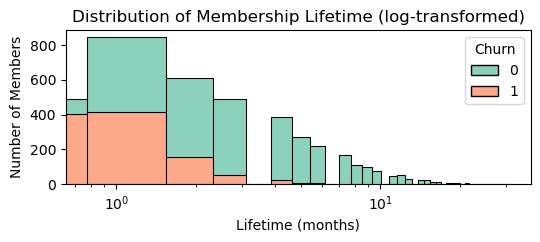

In [10]:
# Show distribution of Lifetime and separate by Churn
plt.figure(figsize=(6,2))
sns.histplot(data=df, x="Lifetime", bins=40, kde=False, hue="Churn", multiple="stack", palette="Set2")
plt.xscale("log")
plt.title("Distribution of Membership Lifetime (log-transformed)")
plt.xlabel("Lifetime (months)")
plt.ylabel("Number of Members")
plt.show()

In [11]:
# Separate data into cohorts based on Lifetime:

df_cohort = df.copy(deep=True)

df_cohort["Cohort"] = pd.cut(x=df_cohort["Lifetime"], bins=[0, 3, 6, 12, np.inf], right=False,
                             labels=["New", "Early", "Established", "Loyal"], retbins=False,
                             precision=3, include_lowest=True, duplicates='raise', ordered=True)

In [12]:
# Create summary with member counts, and means of numerical variables by cohort
cohort_summary = (df_cohort.groupby("Cohort", observed=False)
                .agg(Member_Count=("Churn", "size"),
                     Member_Perc=("Churn", lambda x: len(x) / len(df_cohort)),
                     Churn_Perc=("Churn", "mean"),
                     Age_mean=("Age", "mean"),
                     Avg_addl_charges_tot_mean =("Avg_additional_charges_total", "mean"),
                     Avg_class_f_tot_mean=("Avg_class_frequency_total", "mean"),
                     Avg_class_f_cm_mean=("Avg_class_frequency_current_month", "mean")))

cohort_summary["Member_Perc"] = (cohort_summary["Member_Perc"] * 100)
cohort_summary["Churn_Perc"]  = (cohort_summary["Churn_Perc"] * 100)

style_table(cohort_summary,"Member Distribution, Churn Rate, and Engagement Metrics by Cohort Group")

,Member_Count,Member_Perc,Churn_Perc,Age_mean,Avg_addl_charges_tot_mean,Avg_class_f_tot_mean,Avg_class_f_cm_mean
Cohort,,,,,,,
New,1940,48.5,50.2,28.5,137.5,1.7,1.5
Early,1146,28.6,7.1,29.8,156.3,2.0,2.0
Established,722,18.1,0.8,30.0,153.8,2.0,2.0
Loyal,192,4.8,0.0,29.7,160.6,2.0,2.0


In [13]:
# Show contingency table of Cohort and Contract_period
pd.crosstab(df_cohort["Cohort"], df_cohort["Contract_period"], normalize="index").map(lambda x: f"{x:.0%}")

Contract_period,1,6,12
Cohort,,,
New,65%,18%,17%
Early,46%,24%,29%
Established,44%,23%,33%
Loyal,48%,22%,30%


In [14]:
# Show contingency table of Cohort and Near_Location
pd.crosstab(df_cohort["Cohort"], df_cohort["Near_Location"], normalize="index").map(lambda x: f"{x:.0%}")

Near_Location,0,1
Cohort,,
New,18%,82%
Early,14%,86%
Established,12%,88%
Loyal,10%,90%


## Building a Predictive Model
---
Train and evaluate a Random Forest model to predict whether a customer churns in the current month given data for the past month.

We split the data into train and test sets. The train set is further split up during grid search for the best model params.

We pre-process the data by scaling numeric variables and one-hot encoding categorical variables, and then run a grid search to find the best parameters for a random forest model, optimizing for average precision.

**Why use average precision during grid search?** Optimizing average precision finds parameters which will work with different thresholds. While metrics like F1 score or recall can also be used during evaluation, they reflect specific trade-offs and are more useful once the business has defined its priorities.

In [15]:
# Print value counts (normalized and raw)
print(df['Churn'].value_counts(normalize=True))
print(df['Churn'].value_counts(normalize=False))

Churn
0    0.73
1    0.27
Name: proportion, dtype: float64
Churn
0    2939
1    1061
Name: count, dtype: int64


The data is imbalanced - only 27% of observations represent customers that churned.

In [16]:
# Split the data
X = df[cat_vars + num_vars]
y = df['Churn']

# Split into training and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define preprocessing for numeric and categorical features
numeric_preprocessing = Pipeline([
    ('scale', StandardScaler())
])

categorical_preprocessing = Pipeline([
    ('encode', OneHotEncoder(drop='first', sparse_output=False))  # one-hot; drop first feature to avoid multicollinearity
])

# Combine into a column transformer
preprocessor = ColumnTransformer([
    ('num', numeric_preprocessing, num_vars),
    ('cat', categorical_preprocessing, cat_vars)
])

In [17]:
# Grid search

# Base pipeline
clf_pipeline = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# Define hyperparameter grid
param_grid = {
    'model__n_estimators': [40,100,200],
    'model__max_depth': [None],
    'model__min_samples_leaf': [1, 3, 5, 7],
    'model__max_features': ['sqrt']
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=clf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='average_precision',
    n_jobs=-1,
    verbose=2
)

# Fit grid search on training data
print("Running Grid Search...")
start_time = time.time()
grid_search.fit(X_train, y_train)
print(f"\nGrid search completed in {time.time() - start_time:.2f} seconds")

Running Grid Search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Grid search completed in 7.44 seconds


In [18]:
print("Best Grid Search Result:\n")
print(f"Average Precision: {grid_search.best_score_:.4f} ± {grid_search.cv_results_['std_test_score'][grid_search.best_index_]:.4f}")
print("Parameters:")
pprint(grid_search.best_params_)

Best Grid Search Result:

Average Precision: 0.9248 ± 0.0078
Parameters:
{'model__max_depth': None,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 3,
 'model__n_estimators': 100}


## Model Evaluation
---

We compute PR-AUC and ROC-AUC, as well as plot the Precision-Recall Curve. We also create a model calibration plot to find whether the model under- and over-estimates the true churn rate.

### Key Findings

The best model reaches a **PR-AUC of 0.93**, compared to a **baseline of 0.27** (the churn rate in the test set). This means the model is much better than random guessing at ranking members by churn risk. It also achieves a **ROC-AUC of 0.97 (baseline = 0.50)**, showing it can reliably separate churners from non-churners overall.

Because churn is relatively rare (about 27% of members), PR-AUC is the more meaningful measure. It shows how well the model balances catching churners (recall) with avoiding false alarms (precision) across all possible decision thresholds.

A calibration plot indicates the model is reasonably well-calibrated overall: predicted probabilities align closely with observed churn rates. The model underpredicts churn probabilities for low-risk members (below ~35% observed churn) and overpredicts for higher-risk members, suggesting mild miscalibration. This pattern could impact decision-making in risk-tiered interventions, particularly if thresholds or interventions assume strict probability accuracy.

Model PR-AUC: 0.930 (baseline = 0.265)
Model ROC-AUC: 0.967 (baseline = 0.500)


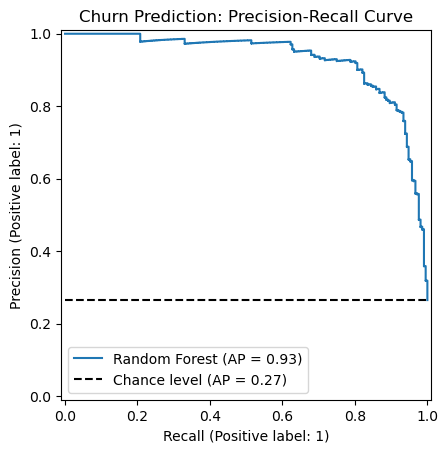

In [19]:
# Use best model from grid search
clf_pipeline = grid_search.best_estimator_

# Get probabilities for Churn = 1
y_test_pred_proba = clf_pipeline.predict_proba(X_test)[:, 1]

print(f"Model PR-AUC: {average_precision_score(y_test, y_test_pred_proba):.3f} (baseline = {y_test.mean():.3f})")
print(f"Model ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba):.3f} (baseline = 0.500)")

# Plot PR curve
display = PrecisionRecallDisplay.from_estimator(clf_pipeline, X_test, y_test, name="Random Forest",
                                                plot_chance_level=True, despine=False)
_ = display.ax_.set_title("Churn Prediction: Precision-Recall Curve")

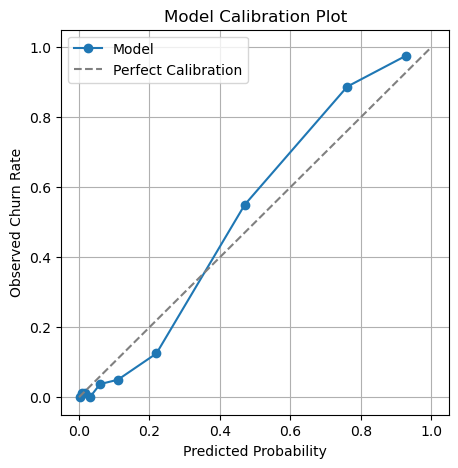

In [28]:
# Calculate model bias

# # Get predicted probabilities and actual outcomes
# y_true = y_test
# y_prob = y_test_pred_proba

# Bin the predicted probabilities (e.g., into 10 bins)
prob_true, prob_pred = calibration_curve(y_test, y_test_pred_proba, n_bins=10, strategy='quantile')

# Plot it
plt.figure(figsize=(5,5))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Predicted Probability')
plt.ylabel('Observed Churn Rate')
plt.title('Model Calibration Plot')
plt.legend()
plt.grid(True)
plt.show()


## Feature Importance
---

To understand what drives churn predictions, we look at feature importance. This tells us which inputs the model relies on most when making decisions. We use two complementary approaches:

- **Random Forest built-in importance**: looks at how often and how strongly a feature is used to split the data inside the trees.
- **Permutation importance**: tests the trained model by shuffling each feature and seeing how much performance drops. This is often more reliable, because it measures impact on actual predictions.

Both methods give a ranking of features, helping us see which factors matter most.

### Key Findings

- The top drivers of churn are consistent across both approaches: Lifetime, recent class frequency and overall class frequency, age, and month to end contract.
- Other features such as referral promotions, group visits, or other demographics (gender, location, phone flag) add little value.

### Business Implications
Retention strategies should prioritize **behavioral engagement** and **contract design**. Since demographics add little predictive value, the best levers are those tied to how and when members use the gym, and not who they are. Tools like attendance tracking, contract incentives, or milestone nudges may be more effective than targeting based on personal traits.

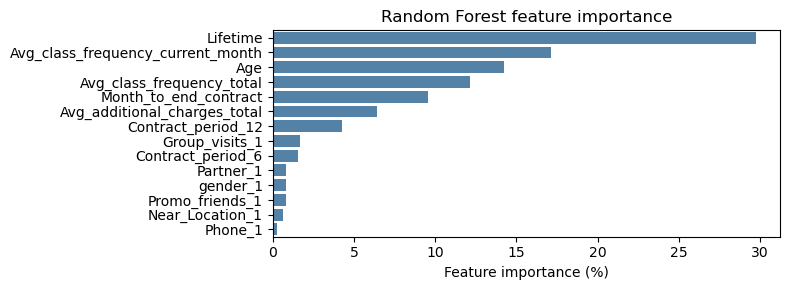

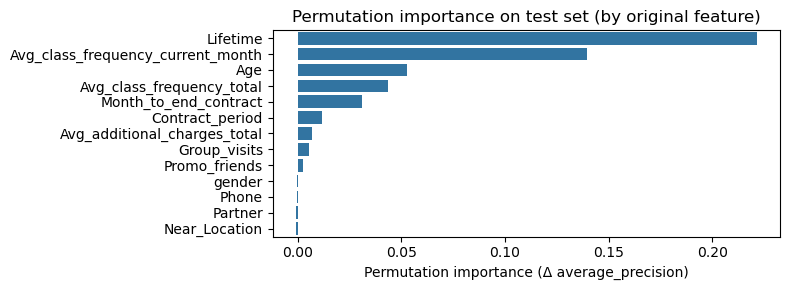

In [21]:
# Feature importance using the RF model itself
model = clf_pipeline.named_steps["model"]
feature_names = clf_pipeline.named_steps["pre"].get_feature_names_out()

# Clean feature names for readability
clean_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

fi = (pd.DataFrame({"feature": clean_names, "importance": model.feature_importances_})
      .sort_values("importance", ascending=False))

# Normalize to percent
fi["importance_pct"] = 100 * fi["importance"] / fi["importance"].sum()

plt.figure(figsize=(8, 3))
sns.barplot(data=fi, y="feature", x="importance_pct", color="steelblue")
plt.xlabel("Feature importance (%)")
plt.ylabel("")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()

# Permutation importance on the full pipeline and original inputs
r = permutation_importance(
    clf_pipeline, X_test, y_test,
    scoring="average_precision",
    n_repeats=10, random_state=42, n_jobs=-1
)

#Use original column names (one per input feature)
orig_feature_names = list(X_test.columns)

pi = (pd.DataFrame({
        "feature": orig_feature_names,
        "mean_importance": r.importances_mean,
        "std": r.importances_std
     }).sort_values("mean_importance", ascending=False))

# Plot features
plt.figure(figsize=(8,3))
sns.barplot(data=pi, y="feature", x="mean_importance")
plt.xlabel("Permutation importance (Δ average_precision)")
plt.ylabel("")
plt.title("Permutation importance on test set (by original feature)")
plt.tight_layout()
plt.show()

## Catching 80% of Churners
---

To meet a key business goal — **identifying at least 80% of members likely to churn** — we use the precision–recall curve to select an appropriate probability threshold. This threshold determines whether a predicted churn probability is labeled as "churn" (1) or "not churn" (0). In this approach, any member with a predicted probability equal to or over the threshold is flagged for churn intervention.

This allows us to align the model's outputs with real-world business needs: maximizing recall while keeping false positives manageable.

### Key Findings

Applying the 80% recall requirement yields:

- Threshold = 0.519 (just above the standard 0.5)
- Recall = 80.2% (we correctly detect 4 out of 5 churners)
- Precision = 92.4% (most flagged members are truly at risk of churn)
- Members flagged = 184 (31% of the test set)

The 80% threshold strikes a balance between catching most churners and limiting unnecessary outreach.

Chosen threshold for recall ≥ 80%: 0.519
At this threshold: Precision=0.924, Recall=0.802


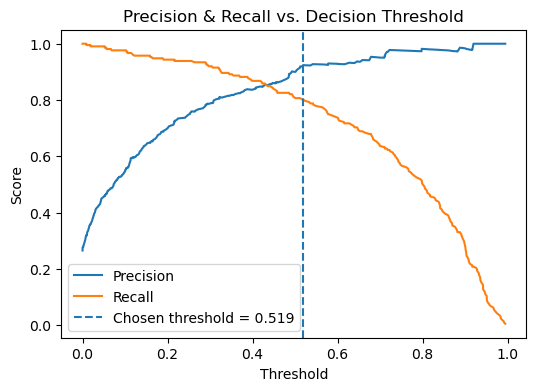

Confusion matrix at chosen threshold [[TN, FP], [FN, TP]]:
[[574  14]
 [ 42 170]]
Churn
0    588
1    212
Name: count, dtype: int64


In [22]:
# Get probabilities for Churn = 1
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]

# Compute precision-recall vs. thresholds
prec, rec, thresholds = precision_recall_curve(y_test, y_proba)

# precision_recall_curve returns one extra point for prec/rec at threshold=-inf
# Align arrays for plotting threshold-based curves
thr = np.r_[thresholds[0], thresholds]  # pad to match lengths for plotting
prec_aligned = np.r_[prec[0], prec[:-1]]
rec_aligned  = np.r_[rec[0],  rec[:-1]]

# Find threshold where recall >= 0.80
target_recall = 0.80
idx = np.where(rec >= target_recall)[0][-1]
best_threshold = thresholds[idx]
best_prec = prec[idx]
best_rec  = rec[idx]

print(f"Chosen threshold for recall ≥ {target_recall:.0%}: {best_threshold:.3f}")
print(f"At this threshold: Precision={best_prec:.3f}, Recall={best_rec:.3f}")

# Plot precision and recall vs threshold
plt.figure(figsize=(6,4))
plt.plot(thr, prec_aligned, label="Precision")
plt.plot(thr, rec_aligned,  label="Recall")
plt.axvline(best_threshold, linestyle="--", label=f"Chosen threshold = {best_threshold:.3f}")
plt.title("Precision & Recall vs. Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

# Compute confusion matrix at the chosen threshold
y_pred_custom = (y_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_custom, labels=[0,1])
print("Confusion matrix at chosen threshold [[TN, FP], [FN, TP]]:")
print(cm)

print(y_test.value_counts(normalize=False))

### Trade-Offs at Different Thresholds

Model performance changes as we vary the probability threshold used to convert churn probabilities into binary yes/no predictions. **Higher thresholds** make the model stricter: fewer members are flagged, precision increases, but more churners are missed (higher false negatives). **Lower thresholds** make the model more lenient: more members are flagged, recall increases, but many are false alarms (higher false positives). The table below shows precision, recall, confusion matrix values, and the percent of members flagged, at thresholds chosen to meet different detection targets (20%, 50%, 80%, and 100% of churners).

### Key Findings

- **80% recall**: The model catches 4 out of 5 churners (recall = 80.2%) with 92.4% precision. Only 23% of members are flagged, which is a strong trade-off.
- **50% recall**: Just half the churners are flagged, but precision reaches 98% (nearly every flagged member is truly at risk).
- **100% recall**: No churners are missed, but 83% of members must be flagged.

### Business Implications

Choosing the right threshold is a business decision. Each level of recall corresponds to a different size and quality of the intervention group.

- **The 80% threshold is a strong default**: It strikes a practical balance between reach and accuracy. Flagging just 23% of members allows for targeted campaigns without overextending staff or budget, while still capturing most of those likely to churn.
- **Higher precision (like the 98% at 50% recall)** may be useful when resources are extremely limited, ensuring that nearly every flagged member truly needs attention, at the cost of missing half the churners.
- **Full coverage (100% recall)** comes with diminishing returns. It may only be viable when intervention is low-cost and scalable (e.g., automated messaging), since 83% of the member base would be flagged (the majority of them false positives).
- **Flexible thresholding supports multiple campaign types**: The model can power both broad awareness nudges and narrow high-risk escalations, depending on the campaign objective, channel, and available resources.

In [23]:
# Define recall levels to target (detection targets)
recall_targets = [0.2, 0.5, 0.8, 1.0]

# Get precision-recall-threshold curve
prec_curve, rec_curve, thr_curve = precision_recall_curve(y_test, y_test_pred_proba)

rows = []
n = len(y_test)

for r_target in recall_targets:
    # Find the highest threshold that still gives recall >= r_target
    idx = np.where(rec_curve >= r_target)[0][-1]
    thr = thr_curve[idx] if idx < len(thr_curve) else 0.0
    
    # Predictions at this threshold
    y_pred_thr = (y_test_pred_proba >= thr).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    prec = precision_score(y_test, y_pred_thr, zero_division=0)
    rec  = recall_score(y_test, y_pred_thr, zero_division=0)
    f1   = f1_score(y_test, y_pred_thr, zero_division=0)
    flagged = tp + fp
    
    rows.append({
        "Detection Target (% churners)": f"{int(r_target*100)}%",
        "Decision Threshold": f"{thr:.3f}",
        "Precision (% of flagged who churn)": f"{prec*100:.1f}%",
        "Recall (% of churners detected)": f"{rec*100:.1f}%",
        # "F1": f"{f1:.3f}",
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "% of all members flagged": f"{flagged/n*100:.1f}%"
    })

df_threshold_summary = pd.DataFrame(rows)
style_table(df_threshold_summary, "Model Precision, Recall, and Confusion Matrix Outcomes at Different Churn Detection Targets")

,Detection Target (% churners),Decision Threshold,Precision (% of flagged who churn),Recall (% of churners detected),TP,FP,FN,TN,% of all members flagged
0,20%,0.926,100.0%,20.3%,43,0,169,588,5.4%
1,50%,0.800,98.1%,50.0%,106,2,106,586,13.5%
2,80%,0.519,92.4%,80.2%,170,14,42,574,23.0%
3,100%,0.009,31.9%,100.0%,212,453,0,135,83.1%


## Building Churn Risk Tiers and Personas
---

In addition to using a single cutoff to classify churn, here we segment members into four **churn risk tiers** based on their predicted churn probability. This helps translate probability scores into actionable groups and allows for graduated retention strategies.

We build a table that splits the data by tier. Each tier displays the number of members, the model's **average predicted churn**, and the **actual churn rate** observed in the data, as well as the top 5 most important variables used in the model. This lets us evaluate how well the model separates risky from safe members.

### Key Findings

- The **Very High** risk tier (≥70% churn probability) contains 17.6% of members and has an observed churn rate of 95%.
- The **High** tier (50–70%) includes 6.1% of members, with a 75.5% churn rate.
- The **Medium** tier (30–50%) shows 42% churn, while the **Low** tier (<30%) has just 3%.
- The model tends to **underestimate churn** in the Medium to Very High groups — observed churn exceeds predicted churn in all cases.

### Risk-Based Personas

By summarizing key traits within each tier, we define personas that reflect real-world member types. These profiles combine tenure, contract type, engagement, and demographics — providing intuitive guidance for targeting.

🟢 **Committed** – Low Risk (<30%)  
- Long gym tenure (~4 months) and stable usage patterns  
- High class engagement (~2x/month, current and overall)  
- Older (~30), with consistent behavior and low churn likelihood  

🟡 **Drifting** – Medium Risk (30–50%)  
- Newer member (~1 month) with moderate attendance  
- Recent decline in engagement (from ~1.7 to ~1.6 classes/month)  
- Slightly younger (~29), showing early signs of disengagement  

🟠 **At-Risk** – High Risk (50–70%)  
- Very recent member (\~1 month), limited attendance (\~1 class/month)  
- Engagement is low and dropping, both currently and overall  
- Young adult (~28), may be ambivalent about continuing  

🔴 **Quitting** – Very High Risk (≥70%)  
- Just joined (0 months of tenure) with almost no activity  
- Current and total class attendance are both low (<1/month)  
- Youngest group (~27), showing immediate signs of churn  

**Note on Feature Selection:** The personas and tier summaries are based on the top predictors identified by the Random Forest model, which prioritized behavioral and contract-related features such as tenure, class attendance, and months remaining. While categorical variables like gender, partner status, or referral source were tested, they had minimal impact on predictive performance and were excluded to keep personas focused on the factors that drive churn most strongly.

**Note on Calibration:** In all tiers except the lowest, the model's predicted churn rates are lower than the actual observed rates. This confirms our earlier findings of calibration bias, where the model tends to underestimate churn risk in medium-to-high probability ranges. While the model is still effective for ranking and segmentation, intervention strategies should be aware that true churn likelihood may be slightly higher than the model predicts, especially for higher-risk members.

### Business Implications
- **Target interventions by tier**: Reserve high-effort tactics (e.g., personalized calls) for High and Very High tiers. Use low-cost nudges (e.g., SMS reminders, emails) for Medium and Low tiers.
- **Use personas to shape messaging**: For example, "Drifting" members may respond to encouragement and routine-building, while "Quitting" members may need immediate re-engagement offers or exit feedback.
- **Integrate into operational tools**: The model can feed into CRM systems or dashboards, providing sales or support teams with live risk scores and suggested personas.
- **Adjust thresholds dynamically**: If campaign capacity changes (e.g., seasonal peak), thresholds can be adapted to expand or narrow intervention groups.

In [24]:
# Build a  DataFrame for the test set
test_df = pd.DataFrame({"actual": y_test.reset_index(drop=True),
                        "p_churn": y_test_pred_proba})

# Define fixed-probability tiers
labels = ["Low (<30%)", "Medium (30%–50%)", "High (50%–70%)", "Very High (≥70%)"]
test_df["risk_tier"] = pd.cut(test_df["p_churn"],
                              bins=[0.0, 0.30, 0.50, 0.70, 1.01],
                              labels=labels,
                              right=False, include_lowest=True)
test_df["risk_tier"] = test_df["risk_tier"].astype(pd.CategoricalDtype(categories=labels, ordered=True))

# Summarize by tier
n = len(test_df)
tier_summary = (test_df.groupby("risk_tier", observed=False)
                .agg(members=("actual", "size"),
                     pred_churn_rate=("p_churn", "mean"),
                     obs_churn_rate=("actual", "mean"))
                    .assign(members_pct=lambda d: d["members"] / n)
                    .reset_index())

# Order columns and format for readability
tier_summary = tier_summary[["risk_tier", "members", "members_pct", "pred_churn_rate", "obs_churn_rate"]]
tier_summary.columns = ["Churn Risk Tier", "Members", "% of Members", "Predicted Churn Rate", "Observed Churn Rate"]

tier_summary["% of Members"]       = (tier_summary["% of Members"] * 100).map(lambda x: f"{x:.1f}%")
tier_summary["Predicted Churn Rate"] = (tier_summary["Predicted Churn Rate"] * 100).map(lambda x: f"{x:.1f}%")
tier_summary["Observed Churn Rate"]  = (tier_summary["Observed Churn Rate"] * 100).map(lambda x: f"{x:.1f}%")

style_table(tier_summary,"Predicted and Observed Churn Rates by Risk Tier")

,Churn Risk Tier,Members,% of Members,Predicted Churn Rate,Observed Churn Rate
0,Low (<30%),553,69.1%,6.1%,3.1%
1,Medium (30%–50%),57,7.1%,40.1%,42.1%
2,High (50%–70%),49,6.1%,60.6%,75.5%
3,Very High (≥70%),141,17.6%,86.7%,95.0%


In [25]:
# Build risk tier personas

# Get the top 6 features based on permutation importance
persona_features = pi.head(5)['feature']

# Reset test set index and merge with risk tiers
X_test_reset = X_test.reset_index(drop=True)
persona_df = pd.concat([X_test_reset, test_df[["risk_tier", "actual"]]], axis=1)

# Compute median values per tier for selected features
persona_summary = persona_df.groupby("risk_tier", observed=False)[persona_features].median()

# Pull in % of members and churn rate from original tier summary
add_cols = tier_summary.set_index("Churn Risk Tier")[["% of Members", "Observed Churn Rate"]]

persona_summary = persona_summary.merge(add_cols, left_index=True, right_index=True)
persona_summary = persona_summary.reset_index().rename(columns={"risk_tier": "Churn Risk Tier"})

# Reorder columns so "Churn Risk Tier" and the two metrics come first
cols_front = ["Churn Risk Tier", "% of Members", "Observed Churn Rate"]
persona_summary = persona_summary[cols_front + [col for col in persona_summary.columns if col not in cols_front]]

persona_summary = persona_summary.round(1)

style_table(persona_summary, "Average Observed Churn Rate and Median Feature Values by Churn Risk Tier")

,Churn Risk Tier,% of Members,Observed Churn Rate,Lifetime,Avg_class_frequency_current_month,Age,Avg_class_frequency_total,Month_to_end_contract
0,Low (<30%),69.1%,3.1%,4.0,2.0,30.0,2.0,6.0
1,Medium (30%–50%),7.1%,42.1%,1.0,1.6,29.0,1.7,1.0
2,High (50%–70%),6.1%,75.5%,1.0,1.2,28.0,1.4,1.0
3,Very High (≥70%),17.6%,95.0%,0.0,0.9,27.0,1.4,1.0


## Business Insights and Recommendations
---

This analysis provides a data-driven foundation for reducing member churn. We identify the strongest behavioral churn signals, segment members into risk-based personas, and suggest strategies for improving retention. Below, we translate these findings into concrete business recommendations.

### 1. Churn is Behavioral, not Demographic
Churn is driven primarily by **tenure**, **class attendance**, and **contract timing**.
- **Short tenure** is the strongest signal: Most churn happens in the first 3 months.
- **Low recent engagement** (especially in the current month) strongly correlates with churn.
- **Approaching contract end** increases churn risk, especially on 1-month plans.
- **Age** has a small but consistent effect: higher-risk members tend to be slightly younger.

**Recommendation:** Retention strategy should focus on **member behavior and lifecycle**, not personal demographics.

### 2. Use Risk Tiers to Prioritize Interventions
We build a predictive model and use it to segment members into four **churn risk tiers**, each with distinct churn likelihood and behavioral traits:

| Risk Tier         | % of Members | Observed Churn |
|------------------|---------------|-----------------|
| Very High (≥70%) | 17.6%         | 95.0%           |
| High (50–70%)    | 6.1%          | 75.5%           |
| Medium (30–50%)  | 7.1%          | 42.1%           |
| Low (<30%)       | 69.1%         | 3.1%            |

Each tier aligns to a churn persona, from steady "Committed" members to at-risk "Quitting" joiners.

**Recommendations:** Assign marketing and support resources based on tier:
- High & Very High: Use high-touch actions (calls, personalized offers, feedback surveys).
- Medium: Use nudges and check-ins (habit reminders, class suggestions).
- Low: Maintain engagement but avoid unnecessary investment.

### 3. Time Interventions to Tenure and Contract Expiry
Cohort and modeling analysis show that churn likelihood **drops sharply after 3 months**. Members in the **first 1–2 months** are at highest risk, especially if their **contract is ending soon**.

**Recommendations:** 
- Launch onboarding and engagement campaigns in the first 2 months.
- Trigger pre-renewal reminders based on predicted contract end (e.g., 2 weeks out).
- Build in habit formation messaging between weeks 2–6.

### 4. Tailor Messaging Based on Personas
Personas can guide content and tone. For example:
- Drifting (Medium Risk): Slight dip in engagement — respond with reminders or class schedule highlights.
- Quitting (Very High Risk): No activity — try surprise offers or reactivation promos.

**Recommendation:** Use churn personas to drive **campaign content**.

### 5. Integrate the Model into CRM Tools
The model is packaged to return: Churn probability, risk tier, and a binary churn flag

**Recommendations:** 
- Embed scores in CRM dashboards or member management tools.
- Use filters to target campaigns (e.g., "All High-risk members with contract ending in 7 days").
- Refresh predictions regularly (e.g., monthly) and retrain model quarterly to adapt to trends.

### 6. Next Steps and Enhancements
To further strengthen churn prediction and prevention:
- Collect and integrate new features (discussed in **Data Recommendations** section below)
- Test interventions through A/B experiments by risk tier
- Track long-term changes in member behavior post-intervention


## Making Predictions in Practice
---

### Using the Model for New Observations

In this section, we show an example scoring function that, given the past month's data about a gym member, outputs probability of churn for the next month, as well as the risk tier and a binary churn flag based on the 80% decision threshold discussed above.

In [26]:
def predict_churn_from_json(model_pipeline, input_json, threshold=0.519):
    """
    Accepts a dict of features.
    Returns JSON with churn probability, risk tier, and binary prediction.
    """
    # Convert JSON to DataFrame
    input_df = pd.DataFrame([input_json])

    # Predict probability
    p_churn = model_pipeline.predict_proba(input_df)[:, 1][0]

    # Determine risk tier
    bins = [0.0, 0.30, 0.50, 0.70, 1.01]
    # labels = ["Low (<30%)", "Medium (30%–50%)", "High (50%–70%)", "Very High (≥70%)"]
    labels = ["Low", "Medium", "High", "Very High"]
    risk_tier = pd.cut([p_churn], bins=bins, labels=labels, right=False)[0]

    # Apply decision threshold
    churn_prediction = int(p_churn >= threshold)

    # Return JSON-style dict
    return {
        "churn_probability": round(p_churn, 4),
        "churn_risk_tier": str(risk_tier),
        "churn_prediction": churn_prediction
    }

In [27]:
# Example use
print("Example gym member:\n")
print(X_test.iloc[0])
sample_json = X_test.iloc[0].to_dict()
print("\nModel prediction:")
predict_churn_from_json(clf_pipeline, sample_json)

Example gym member:

gender                                1.00
Near_Location                         0.00
Partner                               1.00
Promo_friends                         0.00
Phone                                 1.00
Contract_period                       1.00
Group_visits                          1.00
Age                                  29.00
Avg_additional_charges_total         21.26
Month_to_end_contract                 1.00
Lifetime                              7.00
Avg_class_frequency_total             0.50
Avg_class_frequency_current_month     0.50
Name: 1799, dtype: float64

Model prediction:


{'churn_probability': 0.1849, 'churn_risk_tier': 'Low', 'churn_prediction': 0}

### Notes on Deployment

This model can be deployed as a REST API using `FastAPI` or `Flask`. A sample endpoint could accept JSON input for a new member and return predicted churn probability, risk tier, and churn flag.

Model artifacts (preprocessing pipeline + model) can be serialized with `joblib`. For inference in production, wrap the pipeline with a function or API endpoint that includes tier assignment logic.

## Data Quality and Recommendations
---

### Data Quality and Limitations
- This dataset was downloaded from the Kaggle data science competition platform **([Data Source](https://www.kaggle.com/datasets/adrianvinueza/gym-customers-features-and-churn))**. The data discription does not explain how the data was collected, but it appears that the data may have been generated synthetically.
- User gender is not clear from the binary (0/1) column.
- Some users have`Month_to_end_contract == Contract_period` even though `Lifetime > Contract_period`, which suggests the contract fields reset when a user rejoins, while Lifetime keeps accumulating total time since first signup. We kept all three fields but avoided assuming a fixed relationship between them.

### Data Recommendations
The following are recommendations for improving and adding to the dataset, specifically around what additional data to include.
- **Keep all users in the dataset, including those who churned**. This would allow for survival analysis modeling, where we can create a model that predicts length of time till churn.
- **Keep log of restarts or renewals of contracts**. For example, if a user joined for a month and then renewed each month for 2 months, then decided to go for a 12-month contract, this is valuable information.
- **Track which classes a user has taken**.
- **Track of how long a user spent at the gym**, if the gym requires users to "sign out" when leaving.
- **Track whether user bought items at the gym**, like snacks or equipment.